In [7]:
import numpy as np
import scanpy as sc
import pandas as pd
import anndata as ad

In [3]:
import matplotlib.pyplot as plt

In [4]:
adata = sc.read('C:/Users/aamw4/home/aamw4/mixl_chim_atlas.h5')

In [5]:
adata_chim = adata[adata.obs_names.str.startswith('chim'),:].copy()

In [6]:
adata_atlas = adata[adata.obs_names.str.startswith('atlas'),:].copy()

In [7]:
adata_atlas.obs['comb'] = adata_atlas.obs.celltype.astype('str') + '_' + adata_atlas.obs.stage.astype('str')

In [12]:
adata_chim.obs['comb'] = adata_chim.obs['celltype.mapped'].astype('str') + '_' + adata_chim.obs.stage.astype('str')

In [17]:
df = adata_atlas.obs.groupby('comb').count()

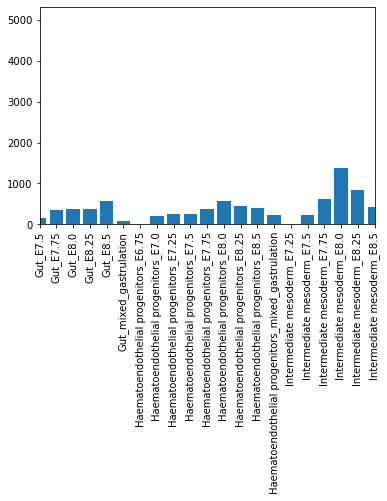

In [18]:
plt.bar(range(254),np.array(list(df['sample'])));
plt.xticks(range(254),df.index, rotation=90);
plt.xlim([120,140])
plt.savefig("C:/Users/aamw4/home/aamw4/haematoendothelial_progenitors_stage_atlas.png")

In [20]:
df2 = adata_chim.obs.groupby('comb').count()

In [21]:
df2

,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,cluster.sub,...,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,sizeFactor,tdTom
comb,,,,,,,,,,,,,,,,,,,,,
Allantois_E8.5,2881,2881,2881,2881,2881,2881,2881,0,0,0,...,0,0,0,2881,2881,2881,2881,2881,2881,2881
Anterior Primitive Streak_E8.5,1,1,1,1,1,1,1,0,0,0,...,0,0,0,1,1,1,1,1,1,1
Blood progenitors 1_E8.5,127,127,127,127,127,127,127,0,0,0,...,0,0,0,127,127,127,127,127,127,127
Blood progenitors 2_E8.5,460,460,460,460,460,460,460,0,0,0,...,0,0,0,460,460,460,460,460,460,460
Cardiomyocytes_E8.5,1225,1225,1225,1225,1225,1225,1225,0,0,0,...,0,0,0,1225,1225,1225,1225,1225,1225,1225
Caudal Mesoderm_E8.5,153,153,153,153,153,153,153,0,0,0,...,0,0,0,153,153,153,153,153,153,153
Caudal epiblast_E8.5,7,7,7,7,7,7,7,0,0,0,...,0,0,0,7,7,7,7,7,7,7
Caudal neurectoderm_E8.5,1,1,1,1,1,1,1,0,0,0,...,0,0,0,1,1,1,1,1,1,1
Def. endoderm_E8.5,444,444,444,444,444,444,444,0,0,0,...,0,0,0,444,444,444,444,444,444,444


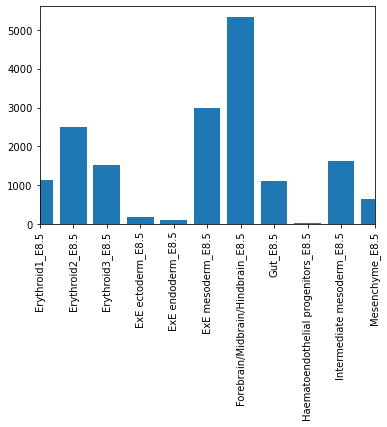

In [23]:
plt.bar(range(34),np.array(list(df2['sample'])));
plt.xticks(range(34),df2.index, rotation=90);
plt.xlim([10,20])
plt.savefig("C:/Users/aamw4/home/aamw4/haematoendothelial_progenitors_stage_wt.png")

In [24]:
sc.pp.neighbors(adata_chim, n_neighbors=30) #or chim

In [25]:
sc.tl.umap(adata_chim)

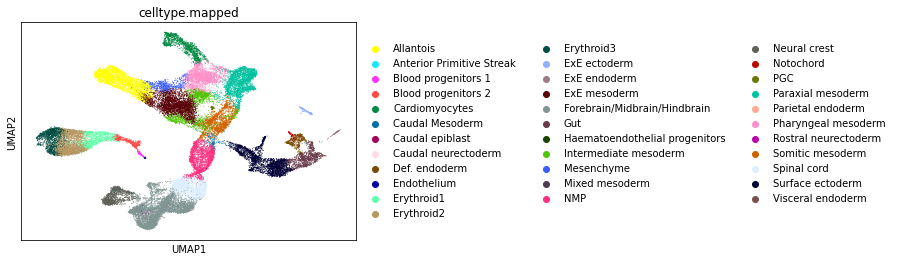

In [151]:
sc.pl.umap(adata_chim, color = 'celltype.mapped')

In [27]:
sc.tl.diffmap(adata_chim)
sc.pp.neighbors(adata_chim, n_neighbors=10, use_rep='X_diffmap')

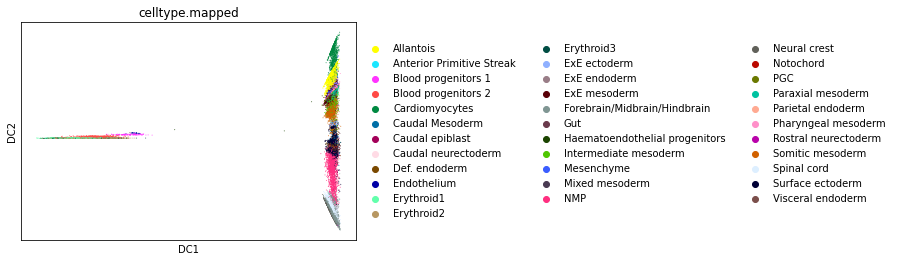

In [40]:
sc.pl.diffmap(adata_chim, color=['celltype.mapped'] )#, legend_loc='on data')

In [ ]:
#whole atlas

In [57]:
sc.pp.neighbors(adata, n_neighbors=15) 

In [58]:
sc.tl.umap(adata)

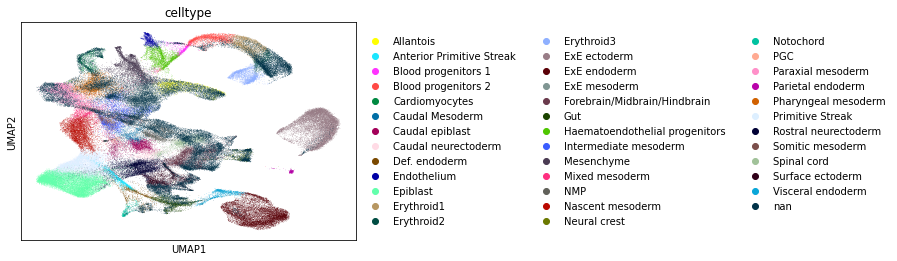

In [60]:
sc.pl.umap(adata, color = 'celltype')

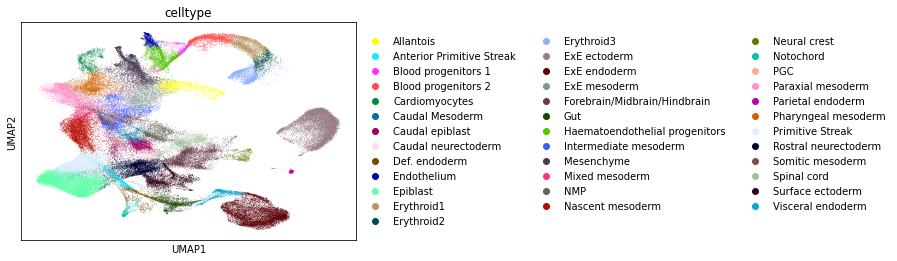

In [72]:
sc.pl.umap(adata_atlas, color = 'celltype')

In [ ]:
sc.tl.diffmap(adata_atlas)
sc.pp.neighbors(adata_atlas, n_neighbors=10, use_rep='X_diffmap')

C:\Users\aamw4\Anaconda3\lib\site-packages\scanpy\neighbors\__init__.py:857: RuntimeWarning: divide by zero encountered in true_divide
  Q = scipy.sparse.spdiags(1.0/q, 0, W.shape[0], W.shape[0])
C:\Users\aamw4\Anaconda3\lib\site-packages\scanpy\neighbors\__init__.py:867: RuntimeWarning: divide by zero encountered in true_divide
  self.Z = scipy.sparse.spdiags(1.0/z, 0, K.shape[0], K.shape[0])


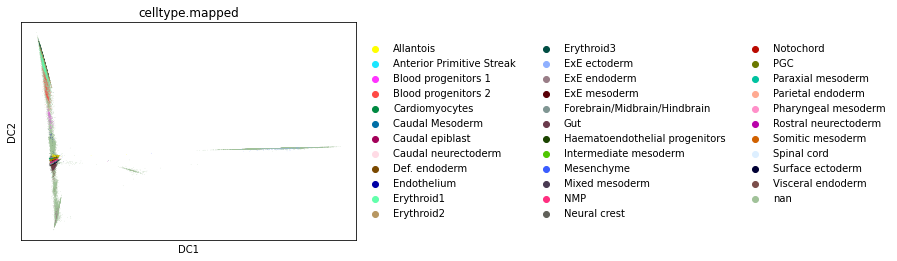

In [66]:
sc.pl.diffmap(adata_atlas, color=['celltype'])

In [ ]:
adata_chim.obs

In [ ]:
#start again here

In [49]:
adata_chim.uns['iroot'] = np.flatnonzero(adata_chim.obs['celltype.mapped']=='Anterior Primitive Streak')[0]

In [50]:
sc.tl.dpt(adata_chim)

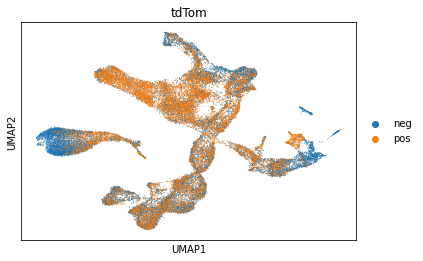

In [56]:
sc.pl.umap(adata_chim, color='tdTom') ##doesn't work here, but same results as Melania

In [ ]:
#realtime against PCA

In [16]:
adata_chim.obs

,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,cluster.sub,...,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,sizeFactor,tdTom
cell,,,,,,,,,,,,,,,,,,,,,
chim_cell_1,mixl_1,E8.5,AAACCCAAGCATAGGC,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,139332,E8.25,Paraxial mesoderm,atlas_cell_74754,1.223278,neg
chim_cell_2,mixl_1,E8.5,AAACCCAAGGGACTGT,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,139333,E8.5,Erythroid3,atlas_cell_134274,0.970827,neg
chim_cell_3,mixl_1,E8.5,AAACCCACAAGCAATA,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,139334,E8.25,Pharyngeal mesoderm,atlas_cell_93757,1.214652,neg
chim_cell_4,mixl_1,E8.5,AAACCCACATCTTCGC,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,139335,E8.25,Forebrain/Midbrain/Hindbrain,atlas_cell_92424,0.985727,neg
chim_cell_5,mixl_1,E8.5,AAACCCAGTATCTCTT,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,139336,E8.5,Forebrain/Midbrain/Hindbrain,atlas_cell_38846,0.763538,neg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chim_cell_43819,mixl_6,E8.5,TTTGGTTTCGGACCAC,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,183150,E8.0,Intermediate mesoderm,atlas_cell_121130,1.029452,pos
chim_cell_43821,mixl_6,E8.5,TTTGTTGGTCACTTAG,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,183152,E8.25,Paraxial mesoderm,atlas_cell_63302,1.902155,pos
chim_cell_43822,mixl_6,E8.5,TTTGTTGGTCCGACGT,1,False,False,nan,NaN,NaN,NaN,...,NaN,NaN,NaN,nan,183153,E8.5,Neural crest,atlas_cell_102526,0.839001,pos


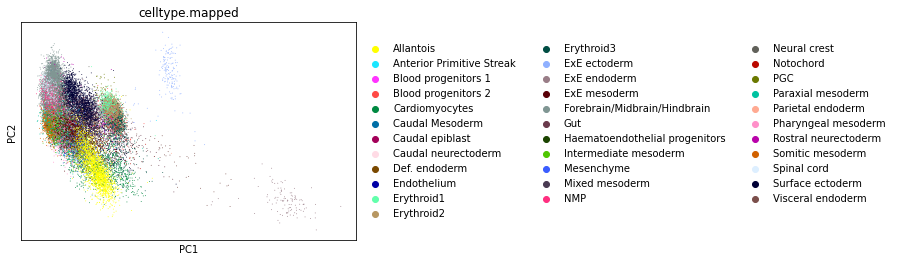

In [17]:
sc.pl.pca(adata_chim, color='celltype.mapped')

In [23]:
adata_chim.obsm['X_pca']

array([[-7.3767871793e-02, -5.8247891630e-02,  4.2525344631e-02, ...,
        -1.0093386242e-02, -9.3273144182e-03,  6.3345309404e-03],
       [ 3.2206900157e-02, -4.8079239680e-02, -3.1374569866e-01, ...,
        -7.2729115223e-04,  1.9122101629e-02,  7.2723128202e-03],
       [-7.8523256934e-02, -4.1425964643e-02,  4.7584115801e-02, ...,
        -5.2975548651e-05,  7.8071655544e-03,  8.9857632597e-03],
       ...,
       [-6.0902134387e-02, -6.7644912677e-03, -2.8493151698e-02, ...,
         4.9187180796e-03, -2.0162841011e-02,  4.0963640437e-03],
       [ 2.0142432058e-03, -1.1241485368e-01,  1.0197663197e-01, ...,
        -7.1390678493e-03,  9.7208873832e-03, -1.8388759528e-02],
       [-7.4665898508e-02, -4.9692104768e-02,  3.0031178978e-02, ...,
        -2.0442046606e-02,  5.0371362657e-03,  1.1093848511e-03]])

In [41]:
adata_chim.obs.shape


(37208, 34)

In [42]:
vec = [0] * 37208

for i in range(37208):
    if adata_chim.obs['stage.mapped'][i].startswith('E'):
        vec[i] = float(str.split(adata_chim.obs['stage.mapped'][i],'E')[1])
    else :
        vec[i] = 10


In [43]:
adata_chim.obs['stage_float'] = vec

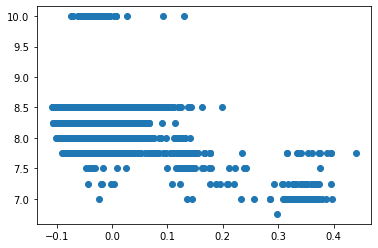

In [44]:
plt.scatter(adata_chim.obsm['X_pca'][:,0], adata_chim.obs['stage_float'])

In [45]:
adata_chim.obs['pca1'] = adata_chim.obsm['X_pca'][:,0]

In [46]:
adata_chim.obs['umap'] = adata_chim.obsm['X_pca'][:,0]

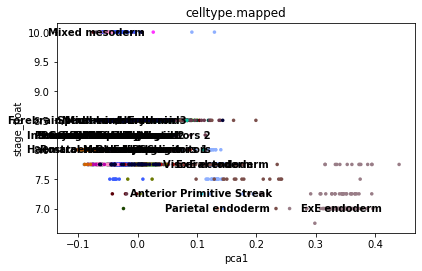

In [47]:
sc.pl.scatter(adata_chim, x='pca1', y='stage_float', color = 'celltype.mapped',size=  50, legend_loc='on data', )

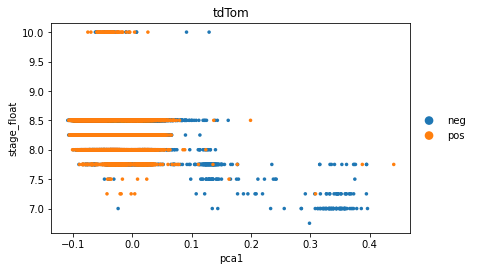

In [81]:
sc.pl.scatter(adata_chim, x='pca1', y='stage_float',color = 'tdTom',size=  50)

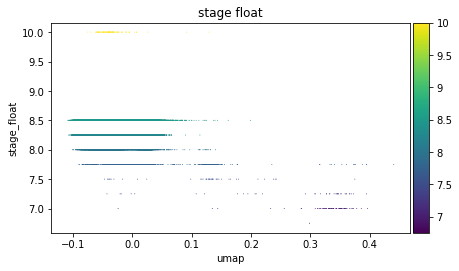

In [55]:
sc.pl.scatter(adata_chim, x="umap", y='stage_float', color='stage_float')

In [148]:
list_names = [name for name in list(df.index) if name in adata_chim.var_names]

adata_chim =  adata_chim[:,list_names].copy()

adata_chim.var_names = list(df.loc[list_names]['Associated Gene Name'])

adata_chim.var_names_make_unique()

adata_chim.var_names

Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27917)

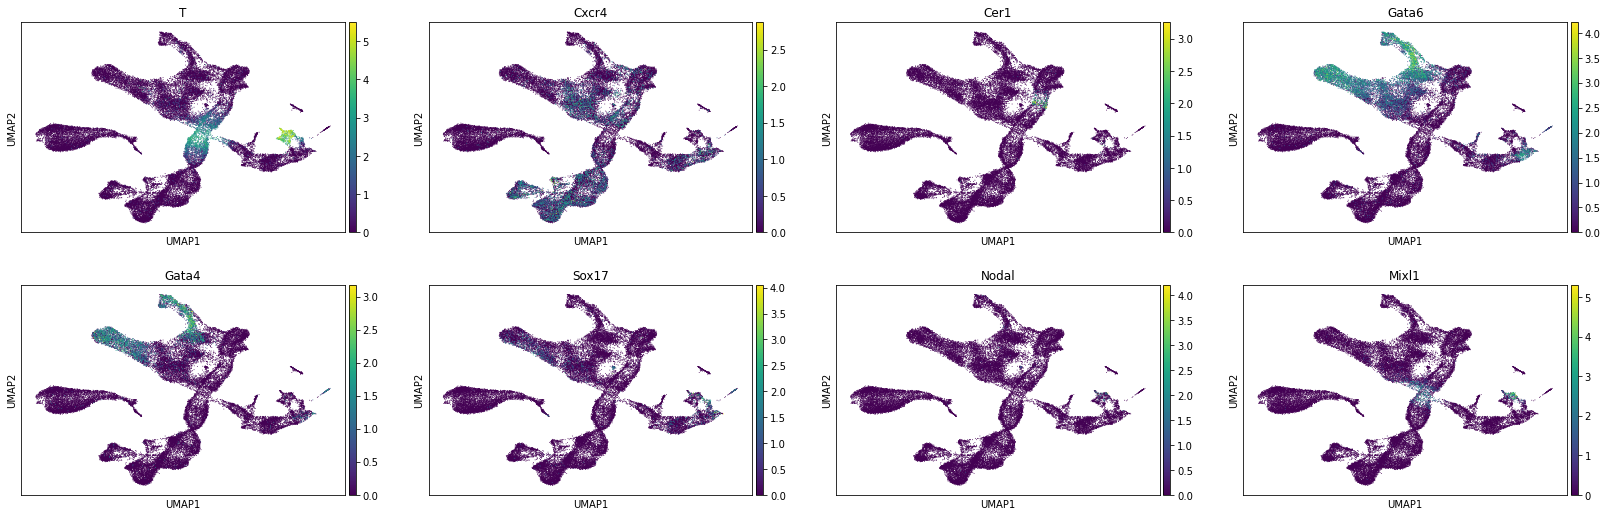

In [153]:
sc.pl.umap(adata_chim, color=["T", "Cxcr4", "Cer1", "Gata6", "Gata4", "Sox17", "Nodal", "Mixl1"])

In [154]:
mixl = ["pos"]

In [159]:
adata_chim

AnnData object with n_obs × n_vars = 37208 × 27917
    obs: 'sample', 'stage', 'barcode', 'sequencing.batch', 'stripped', 'doublet', 'theiler', 'doub.density', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'weight', 'stage.mapped', 'celltype.mapped', 'closest.cell', 'sizeFactor', 'tdTom', 'comb', 'stage_float', 'pca1', 'umap', 'dpt_pseudotime', 'cell', 'meso.mapped'
    uns: 'neighbors', 'umap', 'celltype_colors', 'diffmap_evals', 'celltype.mapped_colors', 'iroot', 'tdTom_colors'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    layers: 'logcounts'
    obsp: 'distances', 'connectivities'

In [155]:
adata_mixl = adata_chim[adata_chim.obs['tdTom'].isin(mixl),:].copy()

In [161]:
adata_mixwt = adata_chim[adata_chim.obs['tdTom']=='neg',:].copy()

In [162]:
adata_mixwt

AnnData object with n_obs × n_vars = 18107 × 27917
    obs: 'sample', 'stage', 'barcode', 'sequencing.batch', 'stripped', 'doublet', 'theiler', 'doub.density', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'weight', 'stage.mapped', 'celltype.mapped', 'closest.cell', 'sizeFactor', 'tdTom', 'comb', 'stage_float', 'pca1', 'umap', 'dpt_pseudotime', 'cell', 'meso.mapped'
    uns: 'neighbors', 'umap', 'celltype_colors', 'diffmap_evals', 'celltype.mapped_colors', 'iroot', 'tdTom_colors'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    layers: 'logcounts'
    obsp: 'distances', 'connectivities'

In [158]:
adata_mixl

AnnData object with n_obs × n_vars = 19101 × 27917
    obs: 'sample', 'stage', 'barcode', 'sequencing.batch', 'stripped', 'doublet', 'theiler', 'doub.density', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'weight', 'stage.mapped', 'celltype.mapped', 'closest.cell', 'sizeFactor', 'tdTom', 'comb', 'stage_float', 'pca1', 'umap', 'dpt_pseudotime', 'cell', 'meso.mapped'
    uns: 'neighbors', 'umap', 'celltype_colors', 'diffmap_evals', 'celltype.mapped_colors', 'iroot', 'tdTom_colors'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    layers: 'logcounts'
    obsp: 'distances', 'connectivities'

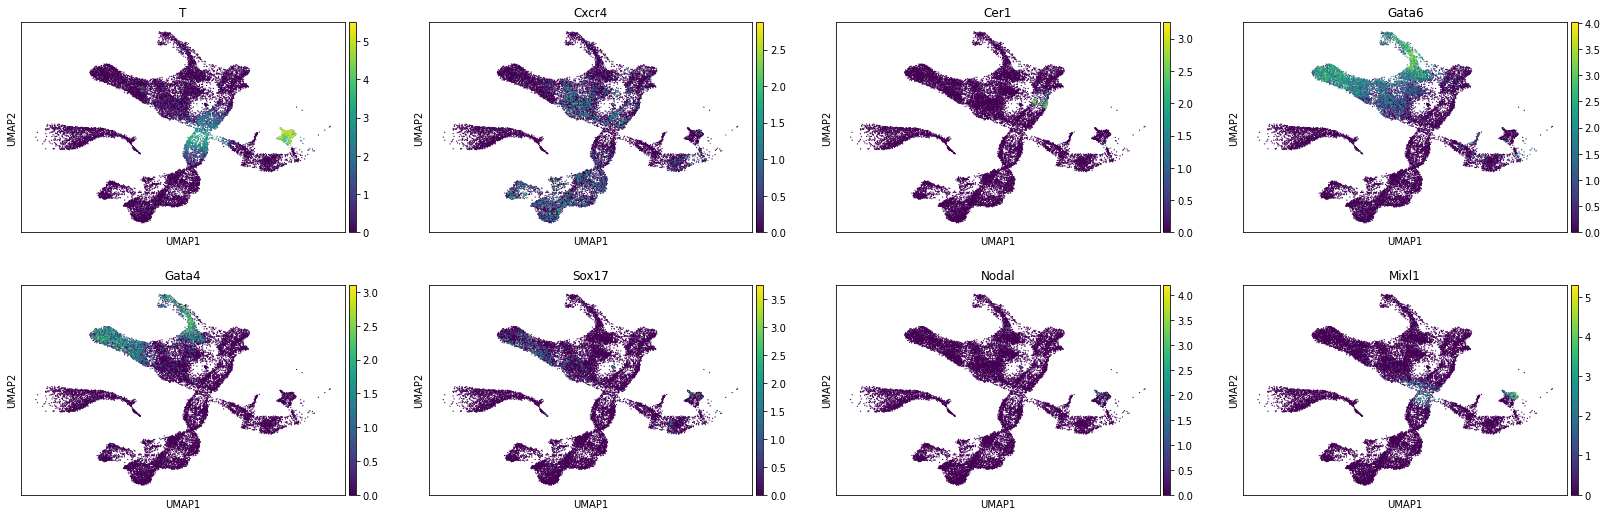

In [157]:
sc.pl.umap(adata_mixl, color=["T", "Cxcr4", "Cer1", "Gata6", "Gata4", "Sox17", "Nodal", "Mixl1"])

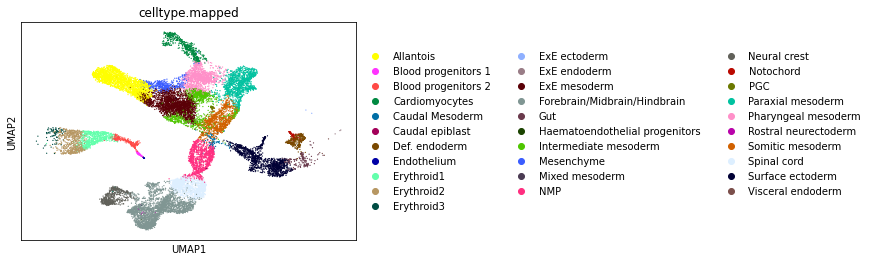

In [160]:
sc.pl.umap(adata_mixl, color="celltype.mapped")

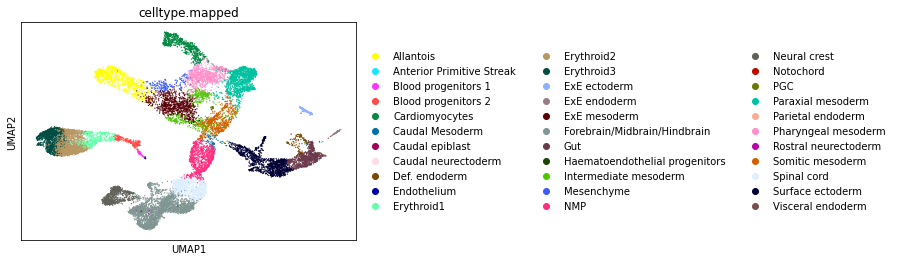

In [163]:
sc.pl.umap(adata_mixwt, color="celltype.mapped")

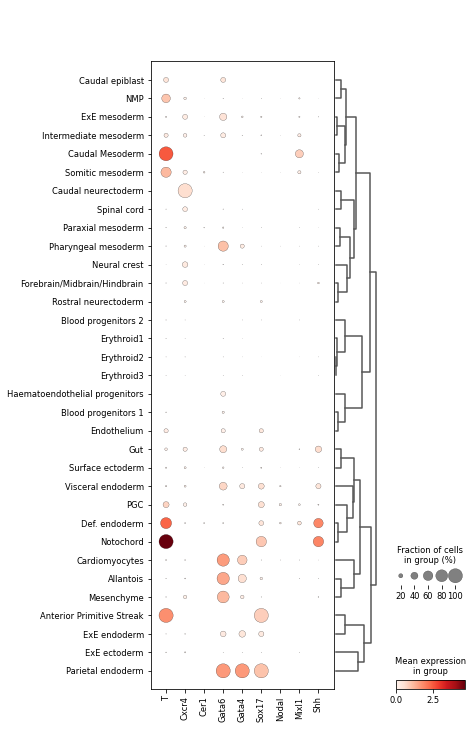

In [173]:
marker_genes_dict = ["T", "Cxcr4", "Cer1", "Gata6", "Gata4", "Sox17", "Nodal", "Mixl1", "Shh", ]

sc.pl.dotplot(adata_mixwt, marker_genes_dict, 'celltype.mapped', dendrogram=True)

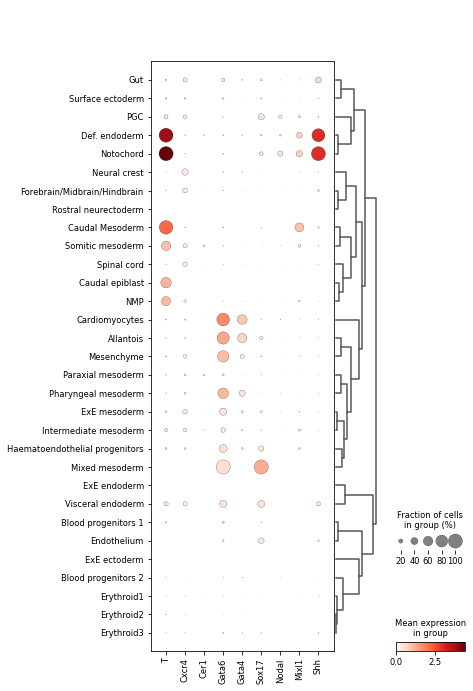

In [174]:
marker_genes_dict = ["T", "Cxcr4", "Cer1", "Gata6", "Gata4", "Sox17", "Nodal", "Mixl1", "Shh", ]

sc.pl.dotplot(adata_mixl, marker_genes_dict, 'celltype.mapped', dendrogram=True)

In [ ]:
#use the refined populations
#do only on subsets (34 total is too much)
#recalculate the PCA's to have maximum variation
#do what we did here but for less celltypes total

#adata Mixl1 chimera
# add gut clusters
chim_tab = pd.read_csv('C:/Users/aamw4/home/aamw4/chimaera_gut_mapped.csv')
gut_subclust = chim_tab[['cell', 'gut_subclust.mapped']]
chim_tab.index = chim_tab.cell
adata_chim.obs = pd.merge(adata_chim.obs, gut_subclust, left_index=True, right_index=True)


# add haem clusters
haem_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/chimaera_haem_mapped.csv')
haem_subclust = haem_subclust[['cell', 'haem_subclust.mapped']]
heam_subclust.index = heam_subclust.cell
adata_chim.obs = pd.merge(adata_chim.obs, haem_subclust, left_index=True, right_index=True)



# add meso clusters
chim_tab = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+meso3.tab', '\t')
meso_subclust = chim_tab[['cell', 'meso.mapped']]
meso_subclust.index = meso_subclust.cell
adata_chim.obs = pd.merge(adata_chim.obs, meso_subclust, left_index=True, right_index=True)

In [90]:
# add meso clusters
chim_tab = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+meso3.tab', '\t')
meso_subclust = chim_tab[['cell', 'meso.mapped']]
meso_subclust.index = meso_subclust.cell
adata_chim.obs = pd.merge(adata_chim.obs, meso_subclust, left_index=True, right_index=True)

In [91]:
adata_chim

AnnData object with n_obs × n_vars = 37208 × 31217
    obs: 'sample', 'stage', 'barcode', 'sequencing.batch', 'stripped', 'doublet', 'theiler', 'doub.density', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'celltype', 'colour', 'umapX', 'umapY', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX', 'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX', 'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'weight', 'stage.mapped', 'celltype.mapped', 'closest.cell', 'sizeFactor', 'tdTom', 'comb', 'stage_float', 'pca1', 'umap', 'dpt_pseudotime', 'cell', 'meso.mapped'
    uns: 'neighbors', 'umap', 'celltype_colors', 'diffmap_evals', 'celltype.mapped_colors', 'iroot', 'tdTom_colors'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    layers: 'logcounts'
    obsp: 'distances', 'connectivities'

#adata_wt WT chimera
string = '-1'
# add gut clusters
wt_tab = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
gut_subclust = wt_tab[['cell', 'gut_subclust.mapped']]
gut_subclust.cell = [cell + string for cell in gut_subclust.cell]
gut_subclust.index = gut_subclust.cell
adata_chim.obs = pd.merge(adata_chim.obs, gut_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

# add haem clusters
#haem_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
haem_subclust = wt_tab[['cell', 'haem_subclust.mapped']]
haem_subclust.cell = [cell + string for cell in haem_subclust.cell]
haem_subclust.index = haem_subclust.cell
adata_chim.obs = pd.merge(adata_chim.obs, haem_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)


# add meso clusters
#meso_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
meso_subclust = wt_tab[['cell', 'meso.mapped']]
meso_subclust.cell = [cell + string for cell in meso_subclust.cell]
meso_subclust.index = meso_subclust.cell
adata_chim.obs = pd.merge(adata_chim.obs, meso_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

In [96]:
meso = ['Anterior-most_somites', 'Dermomyotome', 'Head_mesoderm',
       'Posterior-most_somites', 'Presomitic_mesoderm', 'Sclerotome']

In [102]:
adata_meso = adata_chim[adata_chim.obs['meso.mapped'].isin(meso),:].copy()

In [108]:
adata_meso.obs.columns

Index(['sample', 'stage', 'barcode', 'sequencing.batch', 'stripped', 'doublet',
       'theiler', 'doub.density', 'cluster', 'cluster.sub', 'cluster.stage',
       'cluster.theiler', 'celltype', 'colour', 'umapX', 'umapY',
       'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'endo_gephiX',
       'endo_gephiY', 'endo_trajectoryName', 'endo_trajectoryDPT', 'endo_gutX',
       'endo_gutY', 'endo_gutDPT', 'endo_gutCluster', 'weight', 'stage.mapped',
       'celltype.mapped', 'closest.cell', 'sizeFactor', 'tdTom', 'comb',
       'stage_float', 'pca1', 'umap', 'dpt_pseudotime', 'cell', 'meso.mapped'],
      dtype='object')

In [107]:
sc.tl.pca(adata_meso, svd_solver='arpack')

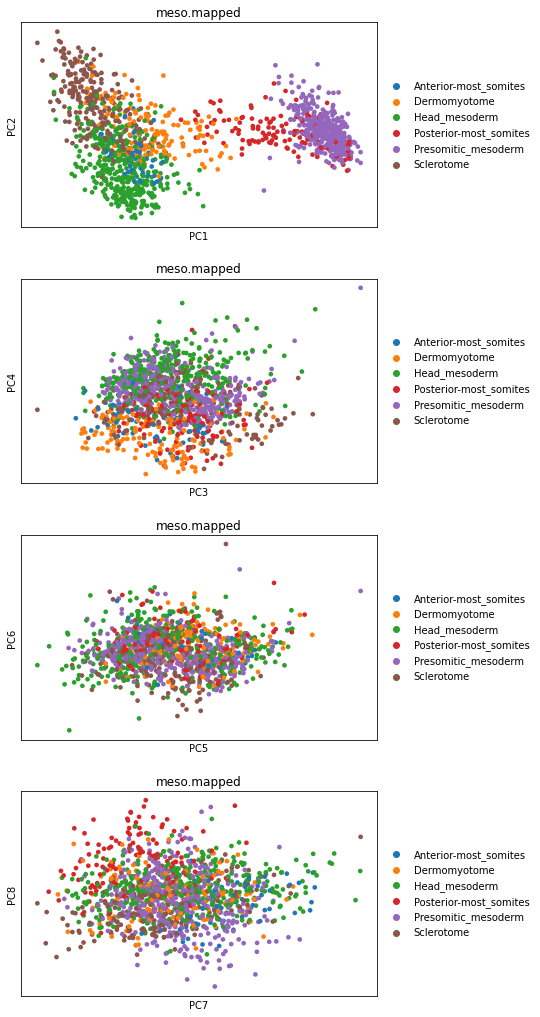

In [111]:
sc.pl.pca(adata_meso, color='meso.mapped', components = ['1,2','3,4','5,6','7,8'], ncols=1)

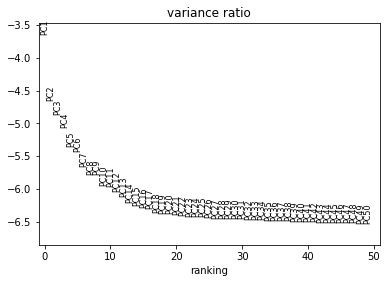

In [113]:
sc.pl.pca_variance_ratio(adata_meso, log=True, n_pcs = 50)

In [120]:
sc.pp.neighbors(adata_meso, n_neighbors = 30)


In [121]:
sc.tl.umap(adata_meso)

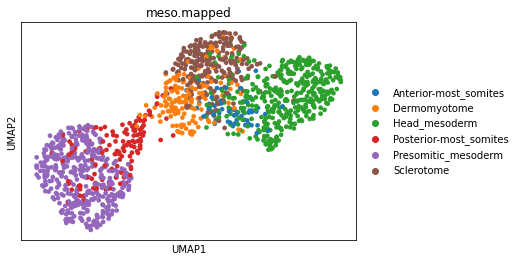

In [122]:
sc.pl.umap(adata_meso, color='meso.mapped')


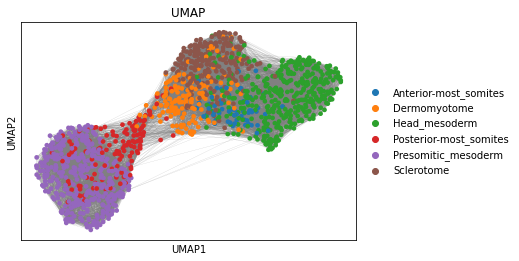

In [123]:
sc.pl.umap(adata_meso, color='meso.mapped', title="UMAP", edges=True)

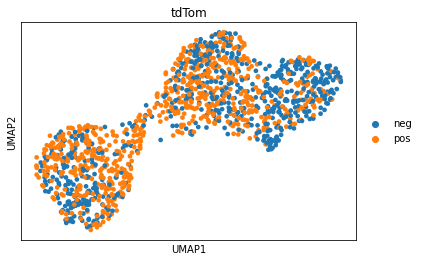

In [124]:
sc.pl.umap(adata_meso, color='tdTom')


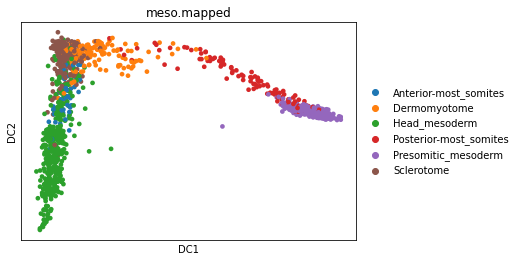

In [125]:
sc.tl.diffmap(adata_meso)
sc.pp.neighbors(adata_meso, n_neighbors=10, use_rep='X_diffmap')

sc.pl.diffmap(adata_meso, color=['meso.mapped'] )#, legend_loc='on data')

In [127]:
np.unique(adata_meso.obs['celltype.mapped'])

array(['Caudal Mesoderm', 'Intermediate mesoderm', 'NMP', 'Neural crest',
       'Paraxial mesoderm', 'Pharyngeal mesoderm', 'Somitic mesoderm',
       'Visceral endoderm'], dtype=object)

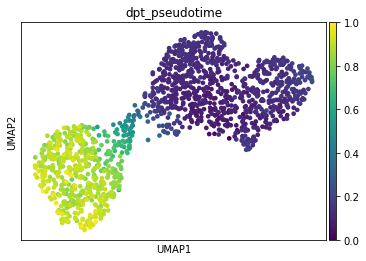

In [130]:
adata_meso.uns['iroot'] = np.flatnonzero(adata_meso.obs['celltype.mapped']=='Visceral endoderm')[0]

sc.tl.dpt(adata_meso)

sc.pl.umap(adata_meso, color='dpt_pseudotime') 

In [133]:
df = pd.read_csv('C:/Users/aamw4/home/aamw4/ensembl_gene_table_81.txt', header=0, sep='\t', index_col=0)
df

,Associated Gene Name,Gene type
Ensembl Gene ID,,
ENSMUSG00000064372,mt-Tp,Mt_tRNA
ENSMUSG00000064371,mt-Tt,Mt_tRNA
ENSMUSG00000064370,mt-Cytb,protein_coding
ENSMUSG00000064369,mt-Te,Mt_tRNA
ENSMUSG00000064368,mt-Nd6,protein_coding
...,...,...
ENSMUSG00000097611,RP24-152F23.3,protein_coding
ENSMUSG00000107101,RP23-465P18.1,antisense
ENSMUSG00000097395,RP24-152F23.5,protein_coding


In [134]:
list_names = [name for name in list(df.index) if name in adata_meso.var_names]

adata_meso =  adata_meso[:,list_names].copy()

adata_meso.var_names = list(df.loc[list_names]['Associated Gene Name'])

adata_meso.var_names_make_unique()

adata_meso.var_names

Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27917)

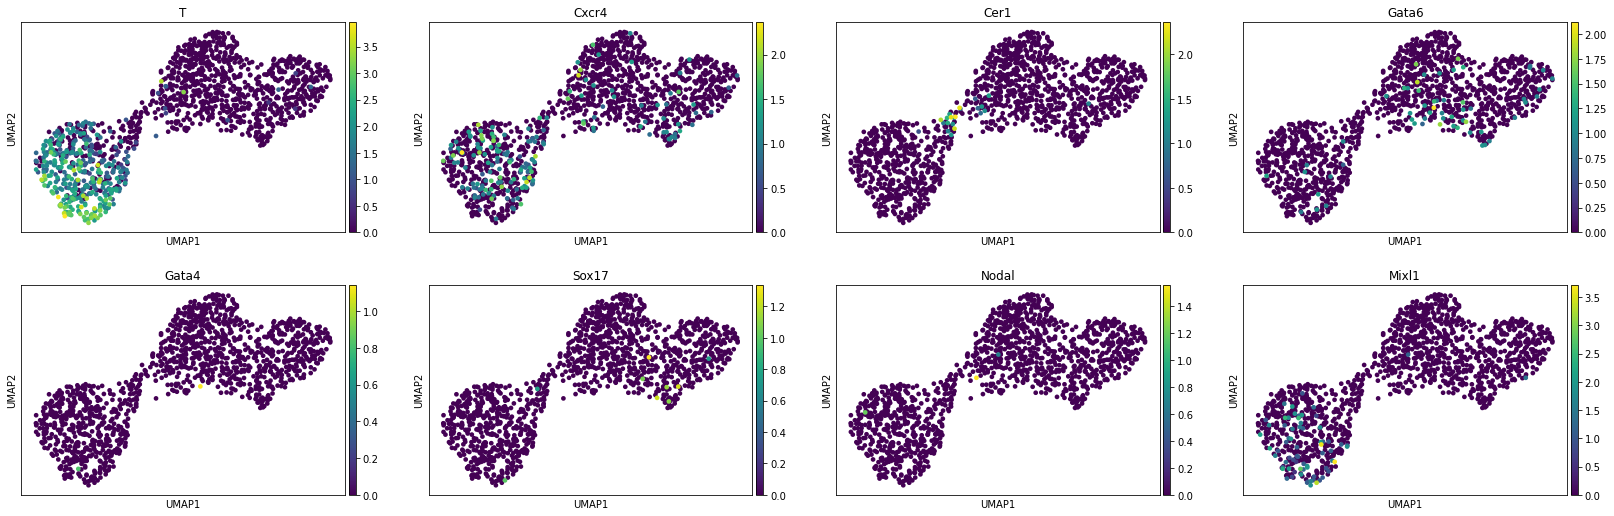

In [152]:
sc.pl.umap(adata_meso, color=["T", "Cxcr4", "Cer1", "Gata6", "Gata4", "Sox17", "Nodal", "Mixl1"])

In [170]:
marker_genes_dict = ["T", "Cxcr4", "Cer1", "Gata6", "Gata4", "Sox17", "Nodal", "Mixl1", "Shh", ]

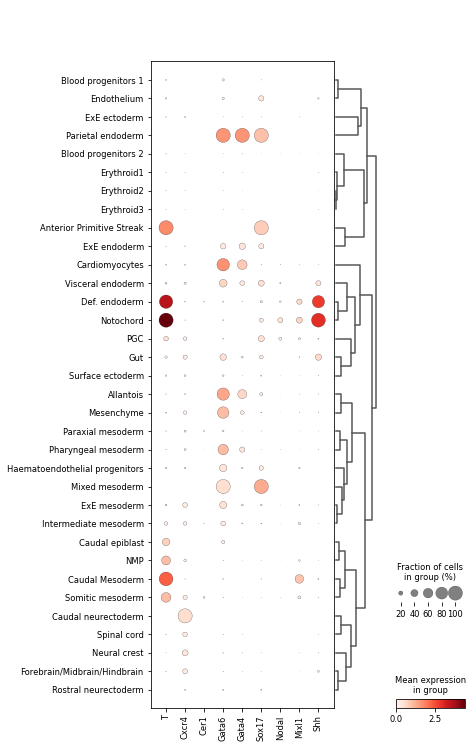

In [172]:
sc.pl.dotplot(adata_chim, marker_genes_dict, 'celltype.mapped', dendrogram=True)

# WT injection

In [1]:
import anndata as ad

In [2]:
adata_wt = ad.read_loom('C:/Users/aamw4/home/aamw4/wt_chim_atlas_analysis.h5')

In [4]:
#subsetting only the chimera cells = won't need atlas cells for now
    
adata_wt = adata_wt[adata_wt.obs_names.str.startswith('wt'),:].copy()

In [8]:
#adata_wt WT chimera
string = '-1'
# add gut clusters
wt_tab = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
gut_subclust = wt_tab[['cell', 'gut_subclust.mapped']]
gut_subclust.cell = [cell + string for cell in gut_subclust.cell]
gut_subclust.index = gut_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, gut_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

# add haem clusters
#haem_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
haem_subclust = wt_tab[['cell', 'haem_subclust.mapped']]
haem_subclust.cell = [cell + string for cell in haem_subclust.cell]
haem_subclust.index = haem_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, haem_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)


# add meso clusters
#meso_subclust = pd.read_csv('C:/Users/aamw4/home/aamw4/big_meta_mapping+haem+meso+gut.tab', '\t')
meso_subclust = wt_tab[['cell', 'meso.mapped']]
meso_subclust.cell = [cell + string for cell in meso_subclust.cell]
meso_subclust.index = meso_subclust.cell
adata_wt.obs = pd.merge(adata_wt.obs, meso_subclust, left_index=True, right_index=True)
#adata.obs = adata.obs.set_index('cell', drop=True)

C:\Users\aamw4\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (6,7,17,26,30,32,37,39,40,41) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
C:\Users\aamw4\Anaconda3\lib\site-packages\pandas\core\generic.py:5168: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


In [12]:
adata_wt

AnnData object with n_obs × n_vars = 13481 × 27151
    obs: 'barcode', 'batch', 'celltype', 'celltype.mapped', 'closest.cell', 'cluster', 'cluster.stage', 'cluster.sub', 'cluster.theiler', 'colour', 'doub.density', 'doublet', 'endo_gephiX', 'endo_gephiY', 'endo_gutCluster', 'endo_gutDPT', 'endo_gutX', 'endo_gutY', 'endo_trajectoryDPT', 'endo_trajectoryName', 'haem_gephiX', 'haem_gephiY', 'haem_subclust', 'sample', 'sequencing.batch', 'sizeFactor', 'stage', 'stage.mapped', 'stripped', 'tdTom', 'theiler', 'umapX', 'umapY', 'gut_subclust.mapped', 'haem_subclust.mapped', 'meso.mapped'
    obsm: 'X_pca', 'X_umap'
    layers: 'logcounts'

In [10]:
#df = pd.read_csv("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/ensembl_gene_table_81.txt", delim_whitespace=True, header=None, skiprows=1, names=['Ensembl Gene ID','Associated Gene Name','Gene type']) #without naming header, didn't work
#df.columns
df = pd.read_csv('C:/Users/aamw4/home/aamw4/ensembl_gene_table_81.txt', header=0, sep='\t', index_col=0)
df

list_names = [name for name in list(df.index) if name in adata_wt.var_names]

adata_wt =  adata_wt[:,list_names].copy()

adata_wt.var_names = list(df.loc[list_names]['Associated Gene Name'])

adata_wt.var_names_make_unique()

adata_wt.var_names

Index(['mt-Cytb', 'mt-Nd6', 'mt-Nd5', 'mt-Nd4', 'mt-Nd4l', 'mt-Nd3', 'mt-Co3',
       'mt-Atp6', 'mt-Atp8', 'mt-Co2',
       ...
       'Impact', 'Dsg3', 'Fam13b', 'Rprd1a', 'Taf4b', 'Zfp521', 'Hrh4', 'Dsc1',
       'Psma8', '2700062C07Rik'],
      dtype='object', length=27151)

In [11]:
adata_wt.obs =  adata_wt.obs.drop(adata_wt.obs.columns[[34, 36, 38]], axis=1)

In [19]:
adata_wt.obs

,barcode,batch,celltype,celltype.mapped,closest.cell,cluster,cluster.stage,cluster.sub,cluster.theiler,colour,...,stage,stage.mapped,stripped,tdTom,theiler,umapX,umapY,gut_subclust.mapped,haem_subclust.mapped,meso.mapped
wt_cell_1-1,AAACCTGAGACCTTTG,1,Haematoendothelial progenitors,Haematoendothelial progenitors,atlas_cell_52006,NaN,NaN,NaN,NaN,nan,...,E7.5,E7.5,0,pos,nan,NaN,NaN,nan,Haem2,nan
wt_cell_2-1,AAACCTGAGCGCCTCA,1,Mesenchyme,Mesenchyme,atlas_cell_33502,NaN,NaN,NaN,NaN,nan,...,E7.5,E8.0,0,pos,nan,NaN,NaN,nan,nan,nan
wt_cell_3-1,AAACCTGAGGATCGCA,1,Primitive Streak,Primitive Streak,atlas_cell_112755,NaN,NaN,NaN,NaN,nan,...,E7.5,E7.0,0,pos,nan,NaN,NaN,nan,nan,nan
wt_cell_4-1,AAACCTGCACGTAAGG,1,NMP,NMP,atlas_cell_68127,NaN,NaN,NaN,NaN,nan,...,E7.5,E8.25,0,pos,nan,NaN,NaN,nan,nan,nan
wt_cell_5-1,AAACCTGCAGACAGGT,1,Caudal Mesoderm,Caudal Mesoderm,atlas_cell_68596,NaN,NaN,NaN,NaN,nan,...,E7.5,E8.25,0,pos,nan,NaN,NaN,nan,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wt_cell_13477-1,TTTGGTTGTGATGCCC,1,Rostral neurectoderm,Rostral neurectoderm,atlas_cell_8750,NaN,NaN,NaN,NaN,nan,...,E8.5,E7.75,0,neg,nan,NaN,NaN,nan,nan,nan
wt_cell_13478-1,TTTGGTTTCGCTTAGA,1,Erythroid3,Erythroid3,atlas_cell_97649,NaN,NaN,NaN,NaN,nan,...,E8.5,E8.5,0,neg,nan,NaN,NaN,nan,Ery4,nan
wt_cell_13479-1,TTTGTCAAGACAATAC,1,Erythroid3,Erythroid3,atlas_cell_38655,NaN,NaN,NaN,NaN,nan,...,E8.5,E8.5,0,neg,nan,NaN,NaN,nan,Ery3,nan
wt_cell_13480-1,TTTGTCAAGGTAGCTG,1,Erythroid2,Erythroid2,atlas_cell_133630,NaN,NaN,NaN,NaN,nan,...,E8.5,E8.5,0,neg,nan,NaN,NaN,nan,Ery2,nan


In [13]:
sc.tl.pca(adata_wt, svd_solver='arpack')

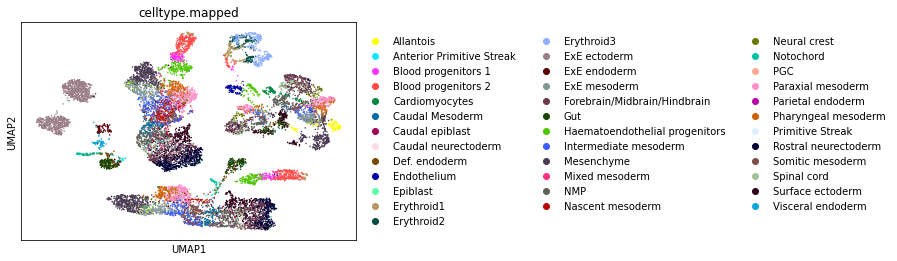

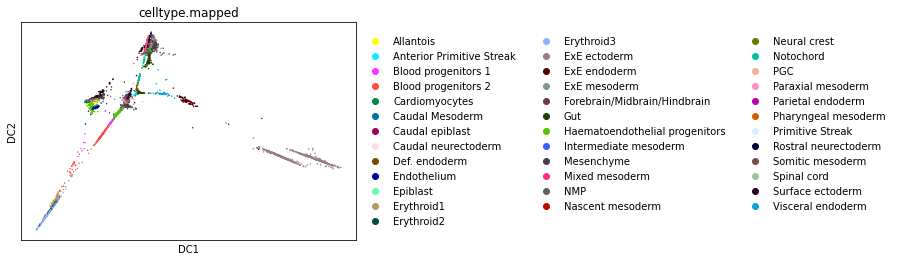

In [20]:
sc.pp.neighbors(adata_wt, n_pcs=20, n_neighbors=10) #or chim

sc.tl.umap(adata_wt)

sc.pl.umap(adata_wt, color = 'celltype.mapped')

sc.tl.diffmap(adata_wt)
sc.pp.neighbors(adata_wt, n_neighbors=10, use_rep='X_diffmap')

sc.pl.diffmap(adata_wt, color=['celltype.mapped'] )#, legend_loc='on data')

In [21]:
adata_wt.obs['sample']

wt_cell_1-1        mixl_1
wt_cell_2-1        mixl_1
wt_cell_3-1        mixl_1
wt_cell_4-1        mixl_1
wt_cell_5-1        mixl_1
                    ...  
wt_cell_13477-1    mixl_6
wt_cell_13478-1    mixl_6
wt_cell_13479-1    mixl_6
wt_cell_13480-1    mixl_6
wt_cell_13481-1    mixl_6
Name: sample, Length: 13481, dtype: category
Categories (6, object): ['mixl_1', 'mixl_2', 'mixl_3', 'mixl_4', 'mixl_5', 'mixl_6']

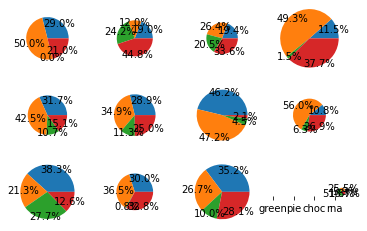

[[1.2510660141e+01 2.1609734803e+01 3.4312445203e-03 9.0699771790e+00]
 [4.4026767245e+00 2.7701578431e+00 5.5878063413e+00 1.0366821811e+01]
 [1.1903024227e+01 1.6164502020e+01 1.2575835432e+01 2.0556585012e+01]
 [6.1335674919e+00 2.6343523092e+01 8.2162779594e-01 2.0114025305e+01]
 [1.2519144071e+01 1.6760694853e+01 4.2116081579e+00 5.9430446725e+00]
 [2.4022337060e+01 2.9047847272e+01 9.4027253448e+00 2.0769678470e+01]
 [2.6291674569e+01 2.6838199905e+01 2.5513263411e+00 1.1716434970e+00]
 [5.0949125869e+00 2.6344275103e+01 2.9504050150e+00 1.2633228750e+01]
 [2.8736685905e+01 1.5994958549e+01 2.0756313419e+01 9.4654689302e+00]
 [2.0595027830e+01 2.5038770157e+01 5.4864832033e-01 2.2504329448e+01]
 [2.9665832667e+01 2.2444969631e+01 8.4133197619e+00 2.3678379854e+01]
 [3.0967801973e+00 1.3436805785e+01 2.7257865093e+01 8.8084244512e+00]]


In [92]:
import matplotlib.pyplot as plt
np.random.seed(1)
t = "Plot a pie chart  with different sized pies all in one figure"
X  = np.random.rand(12,4)*30
r = np.random.rand(12)*0.8+0.6 #change this to fraction of WT to KO
fig, axes= plt.subplots(3, 4) #number of celltypes by number of mapped stages

for i, ax in enumerate(axes.flatten()):
    x = X[i,:]/np.sum(X[i,:])
    ax.pie(x, radius = r[i], autopct="%.1f%%", pctdistance=0.9)
#     ax.set_title(t.split()[i])
    
plt.xticks(range(-20,4,6), ["green", "pie", "choc", "rna"])
plt.show()
print(X)

In [88]:
axes

array([[<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>]],
      dtype=object)